# Replication and validation of the Disneyland tourism analysis

This notebook documents the replication of the analysis of how the opening of Disneyland changed international tourism receipts, measured as a percentage of GDP, in Hong Kong (opened in 2005) and Shanghai (opened in 2016). The data are a panel of nine economies from 1998 to 2019 with gaps, stored in data/raw/disney_did_panel.csv with 177 rows and the columns unit_id, year, receipts_pct_gdp, treated, post, treated_post, study_case and rel_year. The analysis consists of two-way fixed-effects difference-in-differences (DiD) with cluster-robust inference, linear pre-trend tests, wild cluster bootstrap-t inference with the null imposed, event studies, and synthetic control with placebo-in-space inference.

The analysis is implemented in the Python package under src/dtt. The module stata_compat.py is a pure NumPy implementation of the estimation conventions of regress and xtreg (clustered standard errors, small-sample factors, degrees of freedom); no Stata installation is needed. The module did.py holds the DiD estimators, the pre-trend test, the wild cluster bootstrap and the event study. The module scm.py holds the synthetic control and the placebo inference. The module simulate.py generates simulated validation panels. The module replication.py holds the panel loader, the driver run_all that repeats every analysis, and the function check_equivalence that compares the results with the reference values. The reference values are the numbers printed by an independent run of the original analysis. They are stored together with the number of decimals that were printed in data/reference/replication_reference_values.json, and they are labelled REFERENCE wherever they appear in this notebook.

The notebook has three parts. Part 1 uses only the reference values. It shows that the two clustered standard errors reported for the same coefficient follow from each other in closed form, and it draws the event-study coefficients and the placebo results listed in the reference file. Part 2 runs every analysis on the real panel, compares the results with the reference values under explicit tolerances, and prints a PASS/FAIL table. Part 2 is meant to be run on the desktop that holds the real panel: it runs only when the environment variable DTT_RUN_REAL is set to 1 and the file data/raw/disney_did_panel.csv exists. Otherwise the first cell prints "Real-data check: not run (set DTT_RUN_REAL=1 to run on the desktop)" and Part 2 is skipped. Part 3 runs in both cases. It analyses a simulated panel with the same units, year gaps and number of clusters, a known treatment effect and a pre-trend, in order to show that the estimators and the estimation conventions are implemented correctly. Every table and figure of Part 3 is labelled SIMULATED, and none of its numbers is a result from the real data.

In [1]:
import hashlib
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd


def find_root(start=None):
    """Repository root: the nearest parent directory that contains src/dtt."""
    here = Path(start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "src" / "dtt" / "__init__.py").is_file():
            return candidate
    raise FileNotFoundError(f"repository root not found from {here}")


ROOT = find_root()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from dtt import did, replication as rp, scm, simulate, stata_compat as sc

# Real-panel computations run only when DTT_RUN_REAL=1 and the panel file exists.
PANEL_PATH = rp.DEFAULT_PANEL
REAL_RUN = rp.real_run_enabled(PANEL_PATH)
REF = rp.load_targets()  # reference values: {"meta", "values", "tables"}
REF_VALUES = rp.target_values(REF)  # key -> number


def ref_halfwidth(key):
    """Half a unit in the last printed digit of a reference value."""
    return rp.print_halfwidth(REF["values"][key]["dp"])


if REAL_RUN:
    print(f"Real-data check: enabled ({rp.REAL_RUN_VARIABLE}=1)")
    print(f"Panel file found: {PANEL_PATH}")
    print("sha256:", hashlib.sha256(PANEL_PATH.read_bytes()).hexdigest())
else:
    print("Real-data check: not run (set DTT_RUN_REAL=1 to run on the desktop)")
print(f"Reference values loaded: {len(REF_VALUES)} numbers")

Real-data check: not run (set DTT_RUN_REAL=1 to run on the desktop)
Reference values loaded: 1216 numbers


In [2]:
import importlib.metadata as importlib_metadata
import itertools
import warnings

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import statsmodels.api as sm
from cycler import cycler
from scipy import optimize, stats

for pkg in ("numpy", "scipy", "pandas", "statsmodels", "cvxpy", "matplotlib"):
    print(f"{pkg:12s}{importlib_metadata.version(pkg)}")
print(f"{'python':12s}{sys.version.split()[0]}")

SEEDS = {
    "parallel panel": 11,
    "trending panel": 12,
    "wild bootstrap": 42,
    "Monte Carlo": 2026,
    "factor panel": 7,
    "synthetic control starts": 0,
}
print("Seeds:", SEEDS)

Y = "receipts_pct_gdp"
FIG = Path(os.environ.get("DTT_FIGURE_DIR", ROOT / "figures"))  # DTT_FIGURE_DIR overrides the figure directory
FIG.mkdir(parents=True, exist_ok=True)

# Grayscale style: black and shades of gray only; series differ by line style and marker.
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "0.15",
        "axes.labelcolor": "0.0",
        "axes.prop_cycle": cycler(color=["0.0", "0.35", "0.6"], linestyle=["-", "--", ":"]),
        "text.color": "0.0",
        "xtick.color": "0.15",
        "ytick.color": "0.15",
        "axes.grid": True,
        "grid.color": "0.85",
        "grid.linestyle": ":",
        "grid.linewidth": 0.6,
        "font.size": 10,
        "axes.titlesize": 11,
        "legend.frameon": True,
        "legend.edgecolor": "0.4",
        "legend.framealpha": 1.0,
        "image.cmap": "gray",
    }
)


FIGURE_LOG = []  # one record per saved figure, used by the figure inventory at the end


def save_fig(fig, name):
    path = FIG / name
    axes = [a for a in fig.axes if a.get_visible()]
    FIGURE_LOG.append(
        {
            "file": name,
            "panels": len(axes),
            "x labels": list(dict.fromkeys(a.get_xlabel() for a in axes if a.get_xlabel())),
            "y labels": list(dict.fromkeys(a.get_ylabel() for a in axes if a.get_ylabel())),
            "legend entries": sum(len(a.get_legend().get_texts()) for a in axes if a.get_legend() is not None),
        }
    )
    fig.savefig(path, dpi=160, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    print("Figure saved:", path.relative_to(ROOT) if path.is_relative_to(ROOT) else path)


def fig_event_study(frame, base, opening, title, fname, xticks=None, xlabels=None, truth=None, ci_label="Coefficient and 95% confidence interval", legend_loc="upper left"):
    """Event-study coefficients with confidence intervals; frame has columns rel, coef, lo, hi."""
    fig, ax = plt.subplots(figsize=(7.4, 4.3))
    f = frame[frame.rel != base]
    ax.errorbar(f.rel, f.coef, yerr=[f.coef - f.lo, f.hi - f.coef], fmt="o", color="0.0", ecolor="0.4", elinewidth=1.1, capsize=3, markersize=5, label=ci_label, zorder=3)
    ax.plot([base], [0.0], linestyle="none", marker="s", markersize=6.5, markerfacecolor="white", markeredgecolor="0.0", label=f"Base year ({base}), fixed at zero", zorder=4)
    if truth is not None:
        ax.plot(truth["rel"], truth["effect"], color="0.3", linestyle=":", linewidth=2.0, drawstyle="steps-mid", label="True effect (data-generating process)", zorder=2)
    ax.axhline(0.0, color="0.55", linewidth=0.9)
    ax.axvline(-0.5, color="0.2", linestyle="--", linewidth=1.1, label=f"Opening ({opening})")
    ax.set_xlabel(f"Years relative to Disneyland opening ({opening})")
    ax.set_ylabel("Effect on tourism receipts (percentage points of GDP)")
    ax.set_title(title)
    if xticks is not None:
        ax.set_xticks(xticks)
        ax.set_xticklabels(xlabels if xlabels is not None else xticks)
    ax.legend(loc=legend_loc, fontsize=8.5)
    save_fig(fig, fname)


def fig_scm(years, actual, synthetic, first_post, unit, title, fname):
    """Actual and synthetic outcome (upper panel) and their gap (lower panel)."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.4, 6.4), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
    ax1.plot(years, actual, color="0.0", linestyle="-", marker="o", markersize=4.5, linewidth=1.6, label=f"{unit} (actual)")
    ax1.plot(years, synthetic, color="0.35", linestyle="--", marker="^", markersize=5, markerfacecolor="white", linewidth=1.5, label=f"Synthetic {unit}")
    ax1.axvline(first_post - 0.5, color="0.2", linestyle=":", linewidth=1.3, label=f"Opening ({first_post})")
    ax1.set_ylabel("Tourism receipts (% of GDP)")
    ax1.set_title(title)
    ax1.legend(loc="upper left", fontsize=8.5)
    ax2.plot(years, np.asarray(actual) - np.asarray(synthetic), color="0.0", linestyle="-", marker="o", markersize=4, linewidth=1.5, label="Gap: actual minus synthetic")
    ax2.axhline(0.0, color="0.5", linewidth=0.9)
    ax2.axvline(first_post - 0.5, color="0.2", linestyle=":", linewidth=1.3)
    ax2.set_xlabel("Year")
    ax2.set_ylabel("Gap (percentage points of GDP)")
    ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2.legend(loc="upper left", fontsize=8.5)
    fig.tight_layout()
    save_fig(fig, fname)


def fig_placebo(years, gaps, labels, treated, first_post, title, fname):
    """Gaps of all units; the treated unit in thick black, placebo units in dashed gray."""
    fig, ax = plt.subplots(figsize=(7.4, 4.5))
    shown = False
    for j, lab in enumerate(labels):
        if lab == treated:
            continue
        ax.plot(years, gaps[:, j], color="0.6", linestyle="--", linewidth=1.1, label="Placebo gaps (other units)" if not shown else None)
        shown = True
    ax.plot(years, gaps[:, labels.index(treated)], color="0.0", linestyle="-", marker="o", markersize=3.8, linewidth=2.4, label=f"{treated} (treated unit)")
    ax.axhline(0.0, color="0.4", linewidth=0.9)
    ax.axvline(first_post - 0.5, color="0.2", linestyle=":", linewidth=1.3, label=f"Opening ({first_post})")
    ax.set_xlabel("Year")
    ax.set_ylabel("Gap: actual minus synthetic (percentage points of GDP)")
    ax.set_title(title)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3, fontsize=8.5)
    save_fig(fig, fname)

numpy       2.5.3
scipy       1.18.1
pandas      3.0.5
statsmodels 0.15.0
cvxpy       1.9.3
matplotlib  3.11.2
python      3.13.16
Seeds: {'parallel panel': 11, 'trending panel': 12, 'wild bootstrap': 42, 'Monte Carlo': 2026, 'factor panel': 7, 'synthetic control starts': 0}


## Part 1. Standard-error conventions in the reference values

Two programs of the original analysis report a standard error for the same coefficient on the same sample. The program friend_did runs regress with unit and year dummies and vce(cluster unit_id), multiplies the clustered standard error by sqrt(N (G - 1) / (G (N - 1))) and bases inference on t with N - K degrees of freedom. The command xtreg with fe and vce(cluster unit_id) absorbs the unit effects and bases inference on t with G - 1 degrees of freedom. Both rest on the same unscaled cluster sandwich S0. The variance is S0 N / (N - K) in the first case and S0 G/(G - 1) (N - 1) / (N - K + G - 1) in the second, where N is the number of observations, G the number of clusters and K the number of parameters of the dummy-variable regression, equal to N minus the degrees of freedom of friend_did. The ratio of the two standard errors therefore depends on N, G and K only.

The table below applies the relation to the three samples whose standard errors are in the reference values. The prediction starts from the six-decimal standard error of friend_did, while the xtreg standard error has seven decimals. The last two columns give the largest difference that print rounding alone can produce and whether the observed difference lies within it. The numbers are REFERENCE values; no estimation is involved.

In [3]:
CASES = [("1a", "Hong Kong, all 5 donors"), ("1b", "Hong Kong, core 3 donors"), ("1c", "Shanghai")]

rows = []
for tag, label in CASES:
    n = int(REF_VALUES[f"log1/friend_did/{tag}/n_obs"])
    g = int(REF_VALUES[f"log1/friend_did/{tag}/n_clusters"])
    k = n - int(REF_VALUES[f"log1/friend_did/{tag}/df"])
    key_rep = f"log1/friend_did/{tag}/se"
    key_xt = f"log2/xtreg_twfe/{tag}/coef/treated_post/se"
    ratio = sc.se_ratio("xtreg_fe", "report", n, g, k)
    predicted = REF_VALUES[key_rep] * ratio
    bound = ratio * ref_halfwidth(key_rep) + ref_halfwidth(key_xt)
    diff = predicted - REF_VALUES[key_xt]
    rows.append(
        {
            "sample": label,
            "N": n,
            "G": g,
            "K": k,
            "K of xtreg": k - (g - 1),
            "SE friend_did (reference)": REF_VALUES[key_rep],
            "SE xtreg (reference)": REF_VALUES[key_xt],
            "SE xtreg (closed form)": predicted,
            "difference": diff,
            "print-rounding bound": bound,
            "within bound": abs(diff) <= bound,
        }
    )
SE_TABLE = pd.DataFrame(rows)
print("Source: REFERENCE values (numbers printed by an independent run of the original analysis). No Python estimation.")
print(
    SE_TABLE.to_string(
        index=False,
        formatters={
            "SE friend_did (reference)": "{:.6f}".format,
            "SE xtreg (reference)": "{:.7f}".format,
            "SE xtreg (closed form)": "{:.7f}".format,
            "difference": "{:+.2e}".format,
            "print-rounding bound": "{:.2e}".format,
        },
    )
)
assert SE_TABLE["within bound"].all()

Source: REFERENCE values (numbers printed by an independent run of the original analysis). No Python estimation.
                  sample   N  G  K  K of xtreg SE friend_did (reference) SE xtreg (reference) SE xtreg (closed form) difference print-rounding bound  within bound
 Hong Kong, all 5 donors 129  6 28          23                  0.171312            0.1824719              0.1824720  +1.25e-07             5.83e-07          True
Hong Kong, core 3 donors  86  4 26          23                  0.214694            0.2405224              0.2405220  -3.68e-07             6.10e-07          True
                Shanghai  48  3 22          20                  0.276902            0.3233765              0.3233759  -5.70e-07             6.34e-07          True


The relation is an algebraic identity, so the remaining differences are print rounding. The same bookkeeping explains the bootstrap statistic that boottest reports after xtreg. With K_w = K - (G - 1) the number of non-absorbed parameters of xtreg including the constant, boottest uses K_w - 1 in the small-sample factor (the constant is not counted), so that its t statistic equals the xtreg t statistic multiplied by sqrt((N - K_w + 1) / (N - K_w)). After regress, boottest uses the full K and reports the regress t statistic unchanged.

In [4]:
rows = []
for tag, label in CASES:
    n = int(REF_VALUES[f"log1/friend_did/{tag}/n_obs"])
    g = int(REF_VALUES[f"log1/friend_did/{tag}/n_clusters"])
    kw = n - int(REF_VALUES[f"log1/friend_did/{tag}/df"]) - (g - 1)
    b = REF_VALUES[f"log2/xtreg_twfe/{tag}/coef/treated_post/coef"]
    key_se = f"log2/xtreg_twfe/{tag}/coef/treated_post/se"
    se = REF_VALUES[key_se]
    t_xt = b / se
    t_pred = t_xt * np.sqrt((n - kw + 1.0) / (n - kw))
    reference = REF_VALUES[f"log2/xtreg_twfe/{tag}/boottest/t"]
    tol = ref_halfwidth(f"log2/xtreg_twfe/{tag}/boottest/t") + t_pred * ref_halfwidth(key_se) / se
    rows.append(
        {
            "model": f"xtreg, {label}",
            "t of the estimation command": t_xt,
            "t of boottest (reference)": reference,
            "t from closed form": t_pred,
            "within print rounding": abs(t_pred - reference) <= tol,
        }
    )
for key, label in (("hk", "regress pre-trend, Hong Kong"), ("sh", "regress pre-trend, Shanghai")):
    key_se = f"log2/pretrend/{key}/coef/c.t#c.treated/se"
    b = REF_VALUES[f"log2/pretrend/{key}/coef/c.t#c.treated/coef"]
    se = REF_VALUES[key_se]
    reference = REF_VALUES[f"log2/pretrend/{key}/boottest/t"]
    tol = ref_halfwidth(f"log2/pretrend/{key}/boottest/t") + abs(b / se) * ref_halfwidth(key_se) / se
    rows.append(
        {
            "model": label,
            "t of the estimation command": b / se,
            "t of boottest (reference)": reference,
            "t from closed form": b / se,
            "within print rounding": abs(b / se - reference) <= tol,
        }
    )
BOOT_T = pd.DataFrame(rows)
print("Source: REFERENCE values (numbers printed by an independent run of the original analysis). No Python estimation.")
print(BOOT_T.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
assert BOOT_T["within print rounding"].all()

Source: REFERENCE values (numbers printed by an independent run of the original analysis). No Python estimation.
                          model  t of the estimation command  t of boottest (reference)  t from closed form  within print rounding
 xtreg, Hong Kong, all 5 donors                      32.3893                    32.5417             32.5417                   True
xtreg, Hong Kong, core 3 donors                      24.4050                    24.5980             24.5980                   True
                xtreg, Shanghai                       2.8612                     2.9118              2.9118                   True
   regress pre-trend, Hong Kong                       4.7349                     4.7349              4.7349                   True
    regress pre-trend, Shanghai                       3.4579                     3.4579              3.4579                   True


The figures below are drawn from the event-study coefficients in the reference file (REFERENCE values). The event-study regressions use xtreg with unit fixed effects, year dummies and standard errors clustered by unit; the base year is the year before the opening, and the end points of the Hong Kong window are binned at -6 and +10. Confidence intervals are the listed ones, based on t with G - 1 degrees of freedom (5 for Hong Kong, 2 for Shanghai). Python has not re-estimated these models.

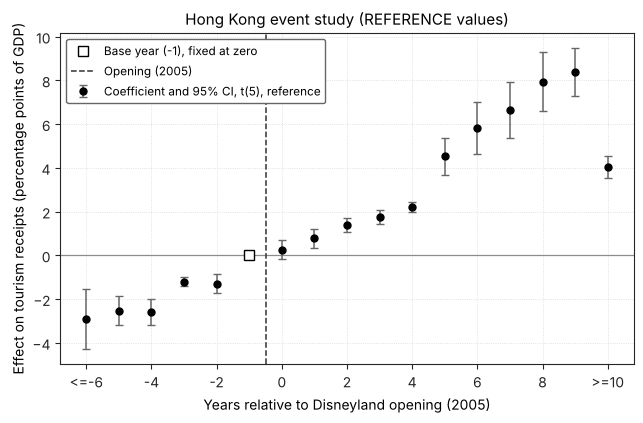

Figure saved: figures/ref_event_study_hk.png


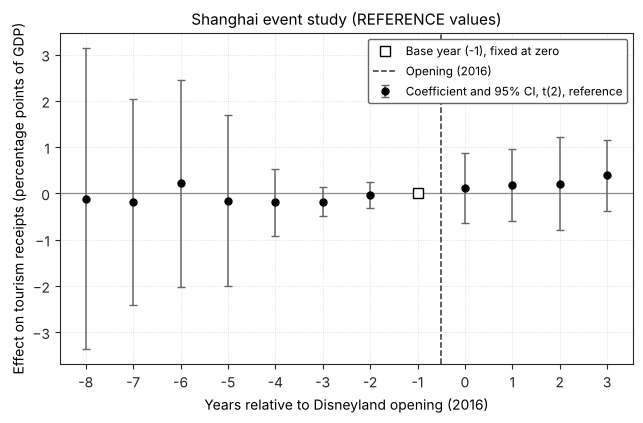

Figure saved: figures/ref_event_study_sh.png


In [5]:
def reference_event_frame(case):
    """Event-study coefficients of one study case from the reference tables (columns rel, coef, lo, hi)."""
    rows = REF["tables"]["event_study"][case]
    return pd.DataFrame(rows).rename(columns={"ci_lo": "lo", "ci_hi": "hi"}).sort_values("rel").reset_index(drop=True)


frame_hk = reference_event_frame("hk")
fig_event_study(
    frame_hk,
    base=-1,
    opening=2005,
    title="Hong Kong event study (REFERENCE values)",
    fname="ref_event_study_hk.png",
    xticks=list(range(-6, 11, 2)),
    xlabels=["<=-6", "-4", "-2", "0", "2", "4", "6", "8", ">=10"],
    ci_label="Coefficient and 95% CI, t(5), reference",
)
frame_sh = reference_event_frame("sh")
fig_event_study(
    frame_sh,
    base=-1,
    opening=2016,
    title="Shanghai event study (REFERENCE values)",
    fname="ref_event_study_sh.png",
    xticks=list(range(-8, 4)),
    ci_label="Coefficient and 95% CI, t(2), reference",
    legend_loc="upper right",
)

The reference values contain two placebo-in-space results for the Hong Kong block. The first ranks all units of the block by the absolute mean post-opening gap, and each placebo run uses every other unit of the block as a donor, including Hong Kong. The second ranks the units by the ratio of post-opening to pre-opening root mean squared prediction error (RMSPE), and the placebo runs for the five donors exclude Hong Kong from their donor pools. With six units the smallest attainable permutation p-value is 1/6. The tables and the figure below show these REFERENCE values. Both panels of the figure use the second set: the left panel orders the units by the ratio and the right panel orders the same units by their signed mean post-opening gap.

Source: REFERENCE values. Hong Kong block, opening 2005.

Units ranked by absolute mean post-opening gap (donor pool of each placebo includes Hong Kong)
 rank        unit  mean gap (pp of GDP)
    1   Hong Kong              6.612050
    2 New Zealand             -3.080338
    3   Singapore             -2.501892
    4 South Korea             -1.720929
    5 Switzerland             -0.460479
    6     Ireland              0.387870

Units ranked by post/pre RMSPE ratio (donor pool of each placebo excludes Hong Kong)
 rank   unit_name  pre_rmspe  post_rmspe     ratio  mean_gap
    1     Ireland   0.032287    0.508405 15.746700  0.391164
    2 Switzerland   0.070643    0.562064  7.956365 -0.463540
    3   Hong Kong   1.086392    7.252910  6.676143  6.612050
    4   Singapore   1.081729    1.277079  1.180590  0.781791
    5 New Zealand   0.792707    0.927822  1.170448  0.082205
    6 South Korea   1.742989    1.739288  0.997877 -1.720929

Hong Kong: rank 1 of 6 by absolute mean gap, permutat

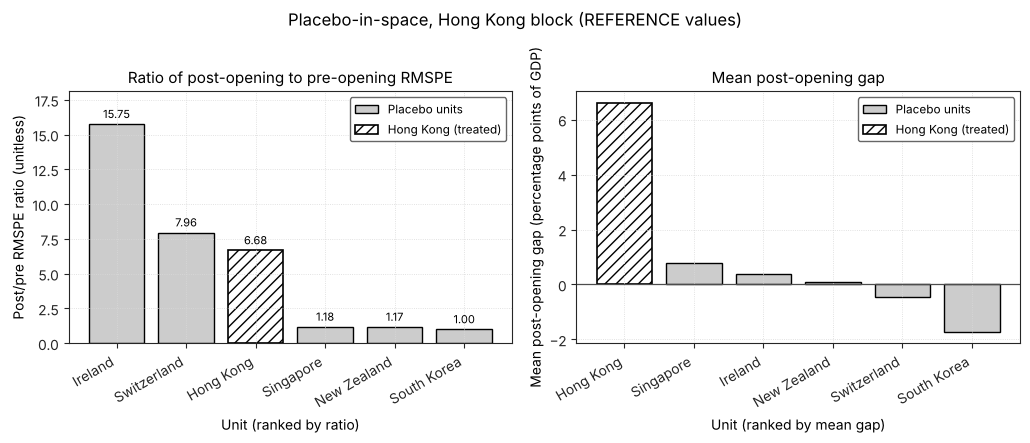

Figure saved: figures/ref_placebo_hk.png


In [6]:
by_ratio = pd.DataFrame(REF["tables"]["placebo_ratio"]["hk"])
by_ratio["unit_name"] = by_ratio.unit_id.map(simulate.UNIT_NAMES)
by_gap = pd.DataFrame(REF["tables"]["placebo_mean_gap"]["hk"])
by_gap["unit"] = by_gap.unit_id.map(simulate.UNIT_NAMES)
print("Source: REFERENCE values. Hong Kong block, opening 2005.\n")
print("Units ranked by absolute mean post-opening gap (donor pool of each placebo includes Hong Kong)")
print(by_gap[["rank", "unit", "mean_gap"]].rename(columns={"mean_gap": "mean gap (pp of GDP)"}).to_string(index=False))
print("\nUnits ranked by post/pre RMSPE ratio (donor pool of each placebo excludes Hong Kong)")
print(by_ratio[["rank", "unit_name", "pre_rmspe", "post_rmspe", "ratio", "mean_gap"]].to_string(index=False))

hk_rank_gap = int(by_gap.loc[by_gap.unit == "Hong Kong", "rank"].iloc[0])
hk_rank_ratio = int(by_ratio.loc[by_ratio.unit_name == "Hong Kong", "rank"].iloc[0])
n_units = len(by_ratio)
print(f"\nHong Kong: rank {hk_rank_gap} of {n_units} by absolute mean gap, permutation p = {hk_rank_gap}/{n_units} = {hk_rank_gap / n_units:.3f}")
print(f"Hong Kong: rank {hk_rank_ratio} of {n_units} by RMSPE ratio, permutation p = {hk_rank_ratio}/{n_units} = {hk_rank_ratio / n_units:.3f}")

fig, (axa, axb) = plt.subplots(1, 2, figsize=(10.4, 4.3))
order = by_ratio.sort_values("ratio", ascending=False)
is_hk = (order.unit_name == "Hong Kong").to_numpy()
pos = np.arange(len(order))
axa.bar(pos[~is_hk], order.ratio[~is_hk], color="0.8", edgecolor="0.0", linewidth=1.0, label="Placebo units")
axa.bar(pos[is_hk], order.ratio[is_hk], color="white", edgecolor="0.0", hatch="///", linewidth=1.2, label="Hong Kong (treated)")
for x, v in zip(pos, order.ratio):
    axa.text(x, v + 0.25, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
axa.set_xticks(pos)
axa.set_xticklabels(order.unit_name, rotation=30, ha="right")
axa.set_ylabel("Post/pre RMSPE ratio (unitless)")
axa.set_xlabel("Unit (ranked by ratio)")
axa.set_title("Ratio of post-opening to pre-opening RMSPE")
axa.legend(loc="upper right", fontsize=8.5)
axa.set_ylim(0, order.ratio.max() * 1.15)

order2 = by_ratio.sort_values("mean_gap", ascending=False)
is_hk2 = (order2.unit_name == "Hong Kong").to_numpy()
pos2 = np.arange(len(order2))
axb.bar(pos2[~is_hk2], order2.mean_gap[~is_hk2], color="0.8", edgecolor="0.0", linewidth=1.0, label="Placebo units")
axb.bar(pos2[is_hk2], order2.mean_gap[is_hk2], color="white", edgecolor="0.0", hatch="///", linewidth=1.2, label="Hong Kong (treated)")
axb.axhline(0.0, color="0.3", linewidth=0.9)
axb.set_xticks(pos2)
axb.set_xticklabels(order2.unit_name, rotation=30, ha="right")
axb.set_ylabel("Mean post-opening gap (percentage points of GDP)")
axb.set_xlabel("Unit (ranked by mean gap)")
axb.set_title("Mean post-opening gap")
axb.legend(loc="upper right", fontsize=8.5)
fig.suptitle("Placebo-in-space, Hong Kong block (REFERENCE values)", y=1.02)
fig.tight_layout()
save_fig(fig, "ref_placebo_hk.png")

## Part 2. Real-data replication and equivalence check

This part runs only when the environment variable DTT_RUN_REAL is set to 1 and the panel file data/raw/disney_did_panel.csv exists; it is meant to be run on the desktop that holds the real panel. The function run_all in dtt.replication repeats every analysis of the original study: the three friend_did regressions, the two pre-trend tests with normal inference, the four xtreg fixed-effects regressions with wild cluster bootstrap-t (null imposed, Webb weights), the two pre-trend regressions with t(G - 1) inference and wild bootstrap, the two event studies, the two synthetic controls and both placebo tables. The function check_equivalence then compares every number in the reference file with the Python value under the tolerance of its class.

Counts (observations, clusters, degrees of freedom, ranks) must agree exactly. Estimates, standard errors, test statistics, p-values and confidence limits of regression output must agree to half a unit in the last printed digit plus a relative 1e-9. Bootstrap p-values and confidence limits reported by boottest come from 9,999 random Webb draws, whereas the Python values are exact, obtained by enumerating all 6^G weight vectors; a p-value passes within four binomial standard errors, and a confidence limit passes when it lies in the range obtained by inverting the exact test at levels 0.05 plus or minus four binomial standard errors. For the synthetic control the RMSPE comparison is one-sided (an exact optimiser may reach a lower value than the reference run, never a higher one), weights are compared to 6e-4, balance and gap tables to 4e-3 and placebo RMSPE ratios to a relative 2e-3.

In [7]:
if REAL_RUN:
    PANEL = rp.load_panel(PANEL_PATH)
    print(f"Panel loaded: {len(PANEL)} rows, {PANEL.unit_id.nunique()} units, years {PANEL.year.min()} to {PANEL.year.max()}")
    start = time.perf_counter()
    RESULTS = rp.run_all(PANEL)
    print(f"All analyses completed in {time.perf_counter() - start:.1f} s")
    CHECK = rp.check_equivalence(RESULTS, REF)
    print("\nTolerances used:")
    print(pd.DataFrame(rp.TOLERANCES).T.to_string())
    print()
    print(rp.format_check_table(CHECK))
else:
    print("Part 2 skipped: the real-data check is not run (see the message of the first cell).")

Part 2 skipped: the real-data check is not run (see the message of the first cell).


In [8]:
if REAL_RUN:
    es_hk = RESULTS.objects["event_study"]["hk"].table.rename(columns={"ci_lo": "lo", "ci_hi": "hi"})
    fig_event_study(es_hk, base=-1, opening=2005, title="Hong Kong event study (Python, real panel)", fname="real_event_study_hk.png",
                    xticks=list(range(-6, 11, 2)), xlabels=["<=-6", "-4", "-2", "0", "2", "4", "6", "8", ">=10"], ci_label="Coefficient and 95% CI, t(5)")
    es_sh = RESULTS.objects["event_study"]["sh"].table.rename(columns={"ci_lo": "lo", "ci_hi": "hi"})
    fig_event_study(es_sh, base=-1, opening=2016, title="Shanghai event study (Python, real panel)", fname="real_event_study_sh.png",
                    xticks=list(range(-8, 4)), ci_label="Coefficient and 95% CI, t(2)", legend_loc="upper right")
    for tag, unit in (("hk", "Hong Kong"), ("sh", "Shanghai")):
        obj = RESULTS.objects[f"scm/{tag}"]
        fit = obj["fit"]
        trp = rp.SCM_SPEC[tag][4]
        fig_scm(obj["years"], obj["W"].iloc[:, 0].to_numpy(), fit.synthetic, trp, unit, f"{unit}: actual and synthetic control (Python, real panel)", f"real_scm_{tag}.png")
    pl = RESULTS.objects["placebo_log2/hk"]
    labels = [rp.UNIT_NAMES[int(u)] for u in pl.table.unit]
    fig_placebo(RESULTS.objects["scm/hk"]["years"], pl.gaps, labels, "Hong Kong", 2005, "Hong Kong placebo gaps (Python, real panel)", "real_placebo_hk.png")
else:
    print("Part 2 figures skipped: the real-data check is not run.")

Part 2 figures skipped: the real-data check is not run.


## Part 3. Validation on a simulated panel (SIMULATED)

Everything in this part is generated by simulation and none of it is an estimate from the real data. The simulated panel has the structure of the real panel: nine units in the same two study blocks (Hong Kong with five donors, Shanghai with two), the same years and year gaps (177 rows), a known treatment effect (5.0 percentage points of GDP for Hong Kong from 2005 and 1.0 for Shanghai from 2016), and very few clusters (6, 4 and 3). The treated unit's untreated outcome is a fixed convex combination of the donors plus noise, so the synthetic control has a true solution. Two versions are generated. In the parallel panel the donor trends are parallel to the treated unit's counterfactual trend. In the trending panel the donors have different linear trends, which creates a pre-trend in the treated unit relative to the average donor.

Five properties are checked. Part 3a: each estimator recovers the known effect. Part 3b: the clustered standard errors and the degrees of freedom conventions agree with closed forms and with statsmodels. Part 3c: the wild cluster bootstrap p-value equals the exhaustive enumeration and a brute-force refit of every bootstrap sample. Part 3d: the synthetic-control weights equal independent cvxpy and scipy solutions, also for a pool of 96 economies. Part 3e: the event-study coefficients recover a known effect path.

In [9]:
PAR, TRUTH_PAR = simulate.simulate_panel(seed=SEEDS["parallel panel"], trend_spread=0.0)
TRD, TRUTH_TRD = simulate.simulate_panel(seed=SEEDS["trending panel"], trend_spread=0.5)

print("SIMULATED panels. Nothing below is a result from the real data.")
for name, d, tr in (("parallel panel", PAR, TRUTH_PAR), ("trending panel", TRD, TRUTH_TRD)):
    problems = rp.validate_panel(d)
    print(f"{name}: {len(d)} rows, units {[int(u) for u in sorted(d.unit_id.unique())]}, years {d.year.min()} to {d.year.max()}, true effects {tr.tau}, structural problems: {problems or 'none'}")

coverage = PAR.groupby("unit_id").year.agg(first_year="min", last_year="max", n_rows="count")
coverage.insert(0, "unit", [simulate.UNIT_NAMES[u] for u in coverage.index])
print("\nSIMULATED panel coverage by unit")
print(coverage.to_string())

start = time.perf_counter()
SIM_RES_PAR = rp.run_all(PAR)
print(f"\nrun_all on the SIMULATED parallel panel: {time.perf_counter() - start:.1f} s")
SIM_CHECK = rp.check_equivalence(SIM_RES_PAR, REF)
structural = SIM_CHECK[(SIM_CHECK.kind == "count") & ~SIM_CHECK.key.str.endswith("/rank")]
print(
    f"\nSample structure of the SIMULATED panel against the counts in the reference values: "
    f"{(structural.status == 'PASS').sum()} of {len(structural)} counts equal (observations, clusters, degrees of freedom, "
    f"observations per group, deleted observations)."
)
other = SIM_CHECK[~SIM_CHECK.index.isin(structural.index)]
print(
    f"All other rows compare SIMULATED outcomes with reference values from the real data: {(other.status == 'FAIL').sum()} of {len(other)} rows fail. "
    f"The {(other.status == 'PASS').sum()} rows that pass are values fixed by the panel structure (average observations per group, zero weights), "
    f"p-values printed as 0.000 or 0.0000, ranks that coincide, and one-sided RMSPE comparisons in which the Python value is lower. "
    f"A simulated panel cannot reproduce the real numbers."
)
assert (structural.status == "PASS").all()

SIMULATED panels. Nothing below is a result from the real data.
parallel panel: 177 rows, units [1, 2, 3, 4, 5, 6, 7, 8, 9], years 1998 to 2019, true effects {'Hong Kong': 5.0, 'Shanghai': 1.0}, structural problems: none
trending panel: 177 rows, units [1, 2, 3, 4, 5, 6, 7, 8, 9], years 1998 to 2019, true effects {'Hong Kong': 5.0, 'Shanghai': 1.0}, structural problems: none

SIMULATED panel coverage by unit
                unit  first_year  last_year  n_rows
unit_id                                            
1            Beijing        2005       2019      15
2          Hong Kong        1998       2019      22
3            Ireland        1999       2019      21
4        New Zealand        1998       2018      21
5           Shanghai        2001       2019      19
6           Shenzhen        2006       2019      14
7          Singapore        1998       2018      21
8        South Korea        1998       2019      22
9        Switzerland        1998       2019      22



run_all on the SIMULATED parallel panel: 4.0 s

Sample structure of the SIMULATED panel against the counts in the reference values: 72 of 72 counts equal (observations, clusters, degrees of freedom, observations per group, deleted observations).
All other rows compare SIMULATED outcomes with reference values from the real data: 1106 of 1144 rows fail. The 38 rows that pass are values fixed by the panel structure (average observations per group, zero weights), p-values printed as 0.000 or 0.0000, ranks that coincide, and one-sided RMSPE comparisons in which the Python value is lower. A simulated panel cannot reproduce the real numbers.


### Part 3a. The estimators recover the known effect (SIMULATED)

For each sample the table reports the DiD estimate with the report-formula standard error (inference on t(N - K)), the xtreg estimate with the cluster standard error (inference on t(G - 1)), and the mean post-opening gap of the synthetic control. In the parallel panel the DiD estimators are close to the true effects. In the trending panel the two-way fixed-effects DiD absorbs the differential trend into the treatment effect, while the synthetic control, which matches the pre-opening path, does not.

In [10]:
def block_samples(df):
    hk = df[df.study_case == "Hong Kong"]
    core3 = hk[hk.unit_id.isin([2, 3, 7, 9])]
    sh = df[df.study_case == "Shanghai"]
    return {"Hong Kong, all 5 donors": hk, "Hong Kong, core 3 donors": core3, "Shanghai": sh}


def scm_inputs(df, tag):
    case, units, start_year, end_year, first_post, treated = rp.SCM_SPEC[tag]
    W = rp.wide_block(df, case, units, start_year, end_year)
    W = W[[treated] + [u for u in W.columns if u != treated]]
    return W, W.index.to_numpy() < first_post, first_post


def recovery_table(df, truth, panel_name):
    rows = []
    truth_by_sample = {"Hong Kong, all 5 donors": truth.tau["Hong Kong"], "Hong Kong, core 3 donors": truth.tau["Hong Kong"], "Shanghai": truth.tau["Shanghai"]}
    for label, sub in block_samples(df).items():
        tau = truth_by_sample[label]
        r = did.friend_did(sub)
        x = did.xtreg_twfe(sub).table().loc["treated_post"]
        rows.append({"panel": panel_name, "sample": label, "estimator": "DiD, report-formula SE, t(N-K)", "true effect": tau, "estimate": r.coef, "SE": r.se, "CI low": r.ci_lo, "CI high": r.ci_hi})
        rows.append({"panel": panel_name, "sample": label, "estimator": "xtreg fe, cluster SE, t(G-1)", "true effect": tau, "estimate": x["coef"], "SE": x["se"], "CI low": x["ci_lo"], "CI high": x["ci_hi"]})
    for tag, label, tau in (("hk", "Hong Kong, all 5 donors", truth.tau["Hong Kong"]), ("sh", "Shanghai", truth.tau["Shanghai"])):
        W, pre, _ = scm_inputs(df, tag)
        fit = scm.synth(W.iloc[:, 0].to_numpy(), W.iloc[:, 1:].to_numpy(), pre, method="both", seed=SEEDS["synthetic control starts"])
        rows.append({"panel": panel_name, "sample": label, "estimator": "Synthetic control, mean post gap", "true effect": tau, "estimate": fit.mean_post_gap, "SE": np.nan, "CI low": np.nan, "CI high": np.nan})
    out = pd.DataFrame(rows)
    out["error"] = out["estimate"] - out["true effect"]
    return out


REC_PAR = recovery_table(PAR, TRUTH_PAR, "parallel")
REC_TRD = recovery_table(TRD, TRUTH_TRD, "trending")
for name, tab in (("parallel panel", REC_PAR), ("trending panel", REC_TRD)):
    print(f"SIMULATED {name}: estimates against the known effect (percentage points of GDP)")
    print(tab.drop(columns="panel").to_string(index=False, na_rep="", float_format=lambda v: f"{v:.3f}"))
    print()

# Linear pre-trend test on the pre-opening years (origin of t as in the original program).
rows = []
for name, d in (("parallel", PAR), ("trending", TRD)):
    for label, case, origin in (("Hong Kong 1998-2004", "Hong Kong", 1998), ("Shanghai 2001-2015", "Shanghai", 2001)):
        sub = d[(d.study_case == case) & (d.post == 0)].assign(t=lambda x, o=origin: x.year - o)
        r = did.pretrend_test(sub)
        rows.append({"panel": name, "sample": label, "interaction coef": r.coef, "SE": r.se, "p, t(G-1)": r.p_t, "p, normal": r.p_z, "N": r.n, "G": r.n_clusters})
print("SIMULATED pre-trend tests (coefficient of t x treated)")
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.4f}"))

SIMULATED parallel panel: estimates against the known effect (percentage points of GDP)
                  sample                        estimator  true effect  estimate    SE  CI low  CI high  error
 Hong Kong, all 5 donors   DiD, report-formula SE, t(N-K)        5.000     4.973 0.057   4.861    5.086 -0.027
 Hong Kong, all 5 donors     xtreg fe, cluster SE, t(G-1)        5.000     4.973 0.061   4.818    5.129 -0.027
Hong Kong, core 3 donors   DiD, report-formula SE, t(N-K)        5.000     4.963 0.081   4.801    5.125 -0.037
Hong Kong, core 3 donors     xtreg fe, cluster SE, t(G-1)        5.000     4.963 0.091   4.674    5.252 -0.037
                Shanghai   DiD, report-formula SE, t(N-K)        1.000     0.994 0.054   0.883    1.104 -0.006
                Shanghai     xtreg fe, cluster SE, t(G-1)        1.000     0.994 0.063   0.723    1.264 -0.006
 Hong Kong, all 5 donors Synthetic control, mean post gap        5.000     4.960                        -0.040
                Shanghai

A single simulated panel can mislead, so the same estimators are applied to 300 independently simulated panels for each scenario (seeds 2026 to 2325 for the parallel scenario and 12026 to 12325 for the trending scenario). The table reports bias, standard deviation and the root mean squared error of the Hong Kong estimates around the true effect of 5.0, the bias in units of its Monte Carlo standard error, and the share of 95% confidence intervals that contain the truth for the two DiD inference conventions.

SIMULATED Monte Carlo: 300 panels per scenario, 13.0 s
SIMULATED: Hong Kong effect, true value 5.0 percentage points of GDP
scenario                   estimator  mean estimate   bias    SD  RMSE  bias / MC SE  coverage, t(N-K), report SE  coverage, t(G-1), cluster SE
parallel DiD (two-way fixed effects)          5.001  0.001 0.038 0.038         0.611                        0.943                         0.983
parallel           Synthetic control          4.999 -0.001 0.028 0.028        -0.458                                                           
trending DiD (two-way fixed effects)          8.951  3.951 0.040 3.952      1693.531                        1.000                         1.000
trending           Synthetic control          5.009  0.009 0.115 0.115         1.319                                                           

PASS  parallel panel: DiD unbiased (|bias| < 3 MC SE)
PASS  parallel panel: synthetic control unbiased (|bias| < 3 MC SE)
PASS  trending panel: DiD biased 

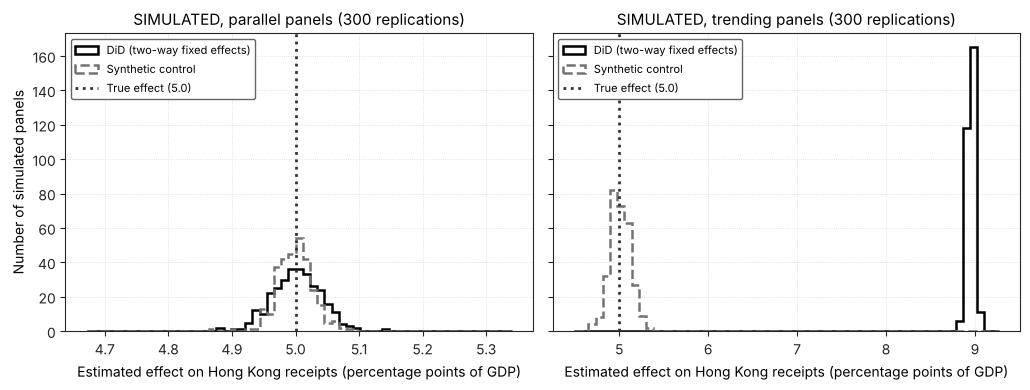

Figure saved: figures/sim_monte_carlo.png


In [11]:
N_REP = 300
TAU_HK = 5.0


def one_replication(seed, spread):
    df, _ = simulate.simulate_panel(seed=seed, trend_spread=spread)
    hk = df[df.study_case == "Hong Kong"]
    r = did.friend_did(hk)
    x = did.xtreg_twfe(hk).table().loc["treated_post"]
    W, pre, _ = scm_inputs(df, "hk")
    s = scm.synth(W.iloc[:, 0].to_numpy(), W.iloc[:, 1:].to_numpy(), pre, method="direct")
    return {
        "DiD": r.coef,
        "SCM": s.mean_post_gap,
        "cover_report": r.ci_lo <= TAU_HK <= r.ci_hi,
        "cover_xtreg": x["ci_lo"] <= TAU_HK <= x["ci_hi"],
    }


start = time.perf_counter()
MC = {}
for scenario, spread, offset in (("parallel", 0.0, 0), ("trending", 0.5, 10_000)):
    MC[scenario] = pd.DataFrame([one_replication(SEEDS["Monte Carlo"] + offset + i, spread) for i in range(N_REP)])
print(f"SIMULATED Monte Carlo: {N_REP} panels per scenario, {time.perf_counter() - start:.1f} s")

rows = []
for scenario, d in MC.items():
    for est, cover in (("DiD (two-way fixed effects)", ("cover_report", "cover_xtreg")), ("Synthetic control", None)):
        e = d["DiD"] if cover else d["SCM"]
        row = {
            "scenario": scenario,
            "estimator": est,
            "mean estimate": e.mean(),
            "bias": e.mean() - TAU_HK,
            "SD": e.std(),
            "RMSE": np.sqrt(((e - TAU_HK) ** 2).mean()),
            "bias / MC SE": (e.mean() - TAU_HK) / (e.std() / np.sqrt(len(e))),
            "coverage, t(N-K), report SE": d[cover[0]].mean() if cover else np.nan,
            "coverage, t(G-1), cluster SE": d[cover[1]].mean() if cover else np.nan,
        }
        rows.append(row)
MC_TABLE = pd.DataFrame(rows)
print("SIMULATED: Hong Kong effect, true value 5.0 percentage points of GDP")
print(MC_TABLE.to_string(index=False, na_rep="", float_format=lambda v: f"{v:.3f}"))

par, trd = MC["parallel"], MC["trending"]
CHECK_A = {
    "parallel panel: DiD unbiased (|bias| < 3 MC SE)": abs(par.DiD.mean() - TAU_HK) < 3 * par.DiD.std() / np.sqrt(N_REP),
    "parallel panel: synthetic control unbiased (|bias| < 3 MC SE)": abs(par.SCM.mean() - TAU_HK) < 3 * par.SCM.std() / np.sqrt(N_REP),
    "trending panel: DiD biased (|bias| > 1 pp)": abs(trd.DiD.mean() - TAU_HK) > 1.0,
    "trending panel: synthetic control nearly unbiased (|bias| < 0.1 pp)": abs(trd.SCM.mean() - TAU_HK) < 0.1,
}
print()
for k, v in CHECK_A.items():
    print(("PASS  " if v else "FAIL  ") + k)
assert all(CHECK_A.values())

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.0), sharey=True)
for ax, scenario in zip(axes, ("parallel", "trending")):
    d = MC[scenario]
    lo = min(d.DiD.min(), d.SCM.min(), TAU_HK) - 0.2
    hi = max(d.DiD.max(), d.SCM.max(), TAU_HK) + 0.2
    bins = np.linspace(lo, hi, 60)
    ax.hist(d.DiD, bins=bins, histtype="step", color="0.0", linestyle="-", linewidth=1.8, label="DiD (two-way fixed effects)")
    ax.hist(d.SCM, bins=bins, histtype="step", color="0.45", linestyle="--", linewidth=1.8, label="Synthetic control")
    ax.axvline(TAU_HK, color="0.2", linestyle=":", linewidth=2.0, label="True effect (5.0)")
    ax.set_xlabel("Estimated effect on Hong Kong receipts (percentage points of GDP)")
    ax.set_title(f"SIMULATED, {scenario} panels ({N_REP} replications)")
    ax.legend(loc="upper left", fontsize=8)
axes[0].set_ylabel("Number of simulated panels")
fig.tight_layout()
save_fig(fig, "sim_monte_carlo.png")

### Part 3b. Clustered standard errors and degrees of freedom (SIMULATED)

For each sample of the simulated parallel panel the regression with unit and year dummies is estimated with the Python implementation and with statsmodels (OLS with a cluster-robust covariance matrix, which applies the factor G/(G - 1) (N - 1)/(N - K)). The unscaled sandwich S0 is recovered from the statsmodels covariance by removing that factor, and the closed forms of Part 1 are evaluated from it. The table reports the largest relative difference of each quantity. The degrees of freedom are N - K for friend_did and G - 1 for xtreg, and the p-values and confidence limits are recomputed with scipy from the corresponding t distribution.

In [12]:
def rel(a, b):
    return abs(a - b) / max(abs(b), 1e-300)


rows = []


def add(sample, quantity, py, ref, how):
    rows.append({"sample": sample, "quantity": quantity, "Python": py, "reference": ref, "reference computed by": how, "relative difference": rel(py, ref)})


for label, sub in block_samples(PAR).items():
    sub = sub.reset_index(drop=True)
    y, unit, year = sub[Y].to_numpy(), sub.unit_id.to_numpy(), sub.year.to_numpy()
    D = pd.concat([sub[["treated_post"]].astype(float), sc.factor_dummies(unit, "unit"), sc.factor_dummies(year, "year")], axis=1)
    n, g = len(sub), len(np.unique(unit))
    ref = sm.OLS(y, sm.add_constant(D.to_numpy())).fit(cov_type="cluster", cov_kwds={"groups": unit})
    k = ref.params.size
    b_ref, v_ref = ref.params[1], ref.cov_params()[1, 1]
    s0 = v_ref / (g / (g - 1.0) * (n - 1.0) / (n - k))  # unscaled sandwich recovered from statsmodels

    fit = sc.regress(y, D, cluster=unit)
    fd = did.friend_did(sub)
    xt = did.xtreg_twfe(sub)
    xr = xt.table().loc["treated_post"]
    crit_fd, crit_xt = stats.t.isf(0.025, n - k), stats.t.isf(0.025, g - 1)

    add(label, "coefficient", fit.coef("treated_post"), b_ref, "statsmodels OLS")
    add(label, "regress cluster SE", fit.std_err("treated_post"), np.sqrt(v_ref), "statsmodels, cov_type=cluster")
    add(label, "friend_did SE", fd.se, np.sqrt(s0 * n / (n - k)), "sqrt(S0 N/(N-K))")
    add(label, "xtreg SE", xr["se"], np.sqrt(s0 * g / (g - 1.0) * (n - 1.0) / (n - k + g - 1.0)), "sqrt(S0 G/(G-1) (N-1)/(N-K+G-1))")
    add(label, "friend_did p-value", fd.p, 2 * stats.t.sf(abs(fd.coef / fd.se), n - k), f"scipy t distribution, {n - k} df")
    add(label, "xtreg p-value", xr["p"], 2 * stats.t.sf(abs(xr["coef"] / xr["se"]), g - 1), f"scipy t distribution, {g - 1} df")
    add(label, "friend_did CI half-width", 0.5 * (fd.ci_hi - fd.ci_lo), crit_fd * fd.se, f"t(0.975, {n - k}) x SE")
    add(label, "xtreg CI half-width", 0.5 * (xr["ci_hi"] - xr["ci_lo"]), crit_xt * xr["se"], f"t(0.975, {g - 1}) x SE")
    add(label, "friend_did df", fd.df, n - k, "N - K")
    add(label, "xtreg df", xt.df_r, g - 1, "G - 1")
CONV = pd.DataFrame(rows)
print("SIMULATED parallel panel: Python implementation against closed forms and statsmodels")
print(CONV.to_string(index=False, formatters={"Python": "{:.9g}".format, "reference": "{:.9g}".format, "relative difference": "{:.1e}".format}))
CHECK_B = {
    "clustered SE, p-values and CIs agree with closed forms and statsmodels (relative difference < 1e-9)": bool((CONV["relative difference"] < 1e-9).all()),
    "degrees of freedom are N-K for friend_did and G-1 for xtreg": bool((CONV.loc[CONV.quantity.str.endswith("df"), "relative difference"] == 0).all()),
}
for k_, v_ in CHECK_B.items():
    print(("PASS  " if v_ else "FAIL  ") + k_)
assert all(CHECK_B.values())

SIMULATED parallel panel: Python implementation against closed forms and statsmodels
                  sample                 quantity         Python      reference            reference computed by relative difference
 Hong Kong, all 5 donors              coefficient     4.97322912     4.97322912                  statsmodels OLS             1.1e-15
 Hong Kong, all 5 donors       regress cluster SE    0.061994594    0.061994594    statsmodels, cov_type=cluster             4.5e-15
 Hong Kong, all 5 donors            friend_did SE   0.0568136992   0.0568136992                 sqrt(S0 N/(N-K))             4.4e-15
 Hong Kong, all 5 donors                 xtreg SE   0.0605147962   0.0605147962 sqrt(S0 G/(G-1) (N-1)/(N-K+G-1))             8.4e-15
 Hong Kong, all 5 donors       friend_did p-value 4.69677247e-97 4.69677247e-97     scipy t distribution, 101 df             0.0e+00
 Hong Kong, all 5 donors            xtreg p-value 5.05511085e-09 5.05511085e-09       scipy t distribution, 5 df     

### Part 3c. Wild cluster bootstrap: exhaustive enumeration, brute force and Monte Carlo (SIMULATED)

The bootstrap tests the coefficient of treated_post in the xtreg model with the null imposed, Webb six-point weights and clustering by unit. With G clusters there are 6^G weight vectors. The exhaustive p-value in dtt.did uses the sign symmetry of the statistic, so half of the vectors are evaluated and counted twice. The brute-force reference below does not use that algebra: it builds every one of the 6^G bootstrap samples y* = fitted values of the restricted model + w_g times the restricted residuals, re-estimates the dummy-variable regression for each sample, computes the cluster-robust standard error and counts the samples with |t*| greater than |t|. The Monte Carlo value uses 9,999 draws (seed 42), as in the reference run. The last column states how far the Monte Carlo p-value lies from the exact one in binomial standard errors of 9,999 draws.

In [13]:
WEBB = np.array([-np.sqrt(1.5), -1.0, -np.sqrt(0.5), np.sqrt(0.5), 1.0, np.sqrt(1.5)])


def brute_force_wcr(y, X, cluster, j, null=0.0, support=WEBB, tie_tol=1e-9):
    """Wild cluster bootstrap-t p-value (null imposed) by explicit construction and re-estimation of every bootstrap sample."""
    codes = pd.factorize(cluster, sort=True)[0]
    G = codes.max() + 1
    n, k = X.shape
    c = G / (G - 1.0) * (n - 1.0) / (n - k)
    XtXi = np.linalg.inv(X.T @ X)
    a = XtXi[j]
    za = X @ a

    def cluster_se(resid):
        # standard error of coefficient j: sqrt(c * sum_g (a' X_g' e_g)^2), one column per bootstrap sample
        s = np.stack([(za[codes == g][:, None] * resid[codes == g]).sum(axis=0) for g in range(G)])
        return np.sqrt(c * (s**2).sum(axis=0))

    # restricted model: beta_j = null
    Xr = np.delete(X, j, axis=1)
    fitted = Xr @ np.linalg.lstsq(Xr, y - null * X[:, j], rcond=None)[0] + null * X[:, j]
    u = y - fitted
    W = np.array(list(itertools.product(support, repeat=G)))  # all support**G weight vectors
    Ystar = fitted[:, None] + W.T[codes] * u[:, None]
    Bstar = XtXi @ (X.T @ Ystar)
    Estar = Ystar - X @ Bstar
    t_star = (Bstar[j] - null) / cluster_se(Estar)
    b0 = XtXi @ (X.T @ y)
    t_obs = (b0[j] - null) / cluster_se((y - X @ b0)[:, None])[0]
    return float(np.mean(np.abs(t_star) > abs(t_obs) * (1 + tie_tol))), W.shape[0]


rows, BOOT = [], {}
for label, sub in block_samples(PAR).items():
    sub = sub.reset_index(drop=True)
    y, unit, year = sub[Y].to_numpy(), sub.unit_id.to_numpy(), sub.year.to_numpy()
    Xw = pd.concat([sub[["treated_post"]].astype(float), sc.factor_dummies(year, "year")], axis=1)
    exact = did.boottest_xtreg_fe(y, Xw, unit, "treated_post", exhaustive=True, band=(9999, 4.0))
    mc = did.boottest_xtreg_fe(y, Xw, unit, "treated_post", reps=9999, seed=SEEDS["wild bootstrap"], exhaustive=False, ci=False)
    Xd = pd.concat([sub[["treated_post"]].astype(float), sc.factor_dummies(unit, "unit"), sc.factor_dummies(year, "year")], axis=1)
    Xd["_cons"] = 1.0
    p_brute, n_vectors = brute_force_wcr(y, Xd.to_numpy(), unit, 0)
    BOOT[label] = (sub, exact, mc)
    rows.append(
        {
            "sample": label,
            "G": exact.n_clusters,
            "weight vectors": n_vectors,
            "t(G-1)": exact.t_stat,
            "p exhaustive": exact.p_value,
            "p brute force": p_brute,
            "|difference|": abs(exact.p_value - p_brute),
            "p Monte Carlo (9,999)": mc.p_value,
            "MC - exact, binomial SE": (mc.p_value - exact.p_value) / np.sqrt(max(exact.p_value * (1 - exact.p_value), 1 / 9999) / 9999),
            "95% set, exact": f"[{exact.ci[0]:.3f}, {exact.ci[1]:.3f}]",
        }
    )
BOOT_TABLE = pd.DataFrame(rows)
print("SIMULATED parallel panel: wild cluster bootstrap-t, null imposed, Webb weights")
print(BOOT_TABLE.to_string(index=False, formatters={"t(G-1)": "{:.3f}".format, "p exhaustive": "{:.6f}".format, "p brute force": "{:.6f}".format, "|difference|": "{:.1e}".format, "p Monte Carlo (9,999)": "{:.4f}".format, "MC - exact, binomial SE": "{:+.2f}".format}))
CHECK_C = {
    "exhaustive p equals brute-force refit of all 6^G samples (|diff| < 1e-12)": bool((BOOT_TABLE["|difference|"] < 1e-12).all()),
    "number of weight vectors equals 6^G": bool((BOOT_TABLE["weight vectors"] == 6 ** BOOT_TABLE["G"]).all()),
    "Monte Carlo p within 4 binomial SE of the exact p": bool((BOOT_TABLE["MC - exact, binomial SE"].abs() < 4).all()),
}
for k_, v_ in CHECK_C.items():
    print(("PASS  " if v_ else "FAIL  ") + k_)
assert all(CHECK_C.values())

SIMULATED parallel panel: wild cluster bootstrap-t, null imposed, Webb weights
                  sample  G  weight vectors t(G-1) p exhaustive p brute force |difference| p Monte Carlo (9,999) MC - exact, binomial SE  95% set, exact
 Hong Kong, all 5 donors  6           46656 82.569     0.003515      0.003515      0.0e+00                0.0038                   +0.48  [4.066, 5.768]
Hong Kong, core 3 donors  4            1296 55.087     0.023148      0.023148      0.0e+00                0.0221                   -0.70  [3.140, 8.090]
                Shanghai  3             216 16.098     0.138889      0.138889      0.0e+00                0.1404                   +0.44 [-1.976, 4.198]
PASS  exhaustive p equals brute-force refit of all 6^G samples (|diff| < 1e-12)
PASS  number of weight vectors equals 6^G
PASS  Monte Carlo p within 4 binomial SE of the exact p


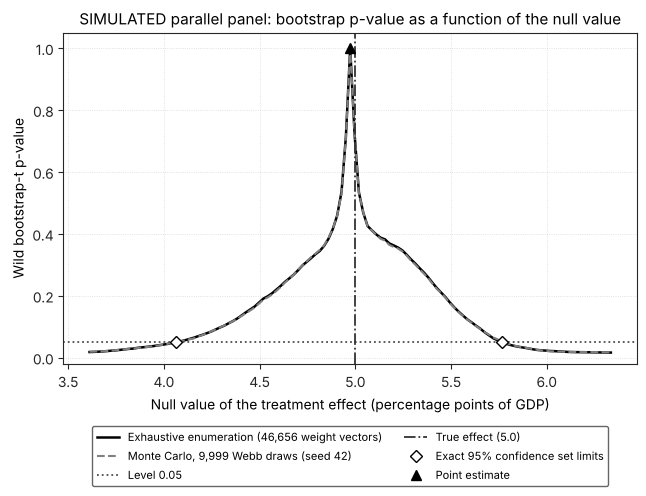

Figure saved: figures/sim_bootstrap_pvalue_function.png
SIMULATED: exact 95% confidence set [4.066, 5.768]; range of the endpoints expected from a 9,999-draw Monte Carlo run: lower 3.987 to 4.124, upper 5.733 to 5.808


In [14]:
# p-value as a function of the null value for Hong Kong (all 5 donors): exhaustive enumeration and 9,999 Monte Carlo draws.
sub, exact, _ = BOOT["Hong Kong, all 5 donors"]
y, unit, year = sub[Y].to_numpy(), sub.unit_id.to_numpy(), sub.year.to_numpy()
Xw = pd.concat([sub[["treated_post"]].astype(float), sc.factor_dummies(year, "year")], axis=1)
half_width = 1.6 * (exact.ci[1] - exact.ci[0]) / 2
grid = np.linspace(exact.coef - half_width, exact.coef + half_width, 121)
p_exact = np.array([did.boottest_xtreg_fe(y, Xw, unit, "treated_post", null=r, exhaustive=True, ci=False).p_value for r in grid])
p_mc = np.array([did.boottest_xtreg_fe(y, Xw, unit, "treated_post", null=r, reps=9999, seed=SEEDS["wild bootstrap"], exhaustive=False, ci=False).p_value for r in grid])

fig, ax = plt.subplots(figsize=(7.4, 4.3))
ax.plot(grid, p_exact, color="0.0", linestyle="-", linewidth=1.8, label=f"Exhaustive enumeration ({6 ** exact.n_clusters:,} weight vectors)")
ax.plot(grid, p_mc, color="0.5", linestyle="--", linewidth=1.5, label="Monte Carlo, 9,999 Webb draws (seed 42)")
ax.axhline(0.05, color="0.3", linestyle=":", linewidth=1.3, label="Level 0.05")
ax.axvline(TRUTH_PAR.tau["Hong Kong"], color="0.2", linestyle="-.", linewidth=1.3, label="True effect (5.0)")
ax.plot(exact.ci, [0.05, 0.05], linestyle="none", marker="D", markersize=6, markerfacecolor="white", markeredgecolor="0.0", label="Exact 95% confidence set limits")
ax.plot([exact.coef], [1.0], linestyle="none", marker="^", markersize=7, color="0.0", label="Point estimate")
ax.set_xlabel("Null value of the treatment effect (percentage points of GDP)")
ax.set_ylabel("Wild bootstrap-t p-value")
ax.set_title("SIMULATED parallel panel: bootstrap p-value as a function of the null value")
ax.set_ylim(-0.02, 1.05)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=2, fontsize=8, frameon=True)
save_fig(fig, "sim_bootstrap_pvalue_function.png")
print(f"SIMULATED: exact 95% confidence set [{exact.ci[0]:.3f}, {exact.ci[1]:.3f}]; range of the endpoints expected from a 9,999-draw Monte Carlo run: lower {exact.ci_band[0][0]:.3f} to {exact.ci_band[0][1]:.3f}, upper {exact.ci_band[1][0]:.3f} to {exact.ci_band[1][1]:.3f}")

### Part 3d. Synthetic control against independent solvers (SIMULATED)

The synthetic-control weights solve a quadratic program on the simplex. The package implements an exact active-set method and two fits: the nested fit (outer optimisation over the predictor weights V with the inner simplex problem solved exactly) and the direct fit (constrained least squares on the pre-opening outcomes). When every pre-opening outcome is a predictor, as in the original analysis, uniform V is optimal for the nested problem, so both fits have the same global optimum. The weights are compared with a cvxpy solution (OSQP at tolerance 1e-12) and a scipy solution (SLSQP with several starts). The maximum absolute weight difference is reported per donor block; the weights are unique when the pre-opening outcome matrix of the donors has full column rank.

In [15]:
import cvxpy as cp


def cvxpy_simplex_ls(y, A):
    """argmin ||y - A w||^2 over the simplex with cvxpy (OSQP at tight tolerance, SCS as fallback)."""
    w = cp.Variable(A.shape[1])
    prob = cp.Problem(cp.Minimize(cp.sum_squares(y - A @ w)), [w >= 0, cp.sum(w) == 1])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        prob.solve(solver=cp.OSQP, eps_abs=1e-12, eps_rel=1e-12, max_iter=500_000, polishing=True)
        if prob.status != "optimal":
            prob.solve(solver=cp.SCS, eps=1e-12, max_iters=500_000)
    assert prob.status in ("optimal", "optimal_inaccurate"), prob.status
    wv = np.maximum(w.value, 0.0)
    return wv / wv.sum()


def scipy_simplex_ls(y, A, n_starts=6, seed=0):
    """argmin ||y - A w||^2 over the simplex with scipy SLSQP (best of several starts)."""
    J = A.shape[1]
    rng = np.random.default_rng(seed)
    best = None
    for s in range(n_starts):
        w0 = np.full(J, 1.0 / J) if s == 0 else rng.dirichlet(np.ones(J))
        res = optimize.minimize(
            lambda w: np.sum((y - A @ w) ** 2),
            w0,
            jac=lambda w: -2.0 * A.T @ (y - A @ w),
            bounds=[(0.0, 1.0)] * J,
            constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1.0, "jac": lambda w: np.ones(J)}],
            method="SLSQP",
            options={"ftol": 1e-15, "maxiter": 1000},
        )
        if best is None or res.fun < best.fun:
            best = res
    wv = np.maximum(best.x, 0.0)
    return wv / wv.sum()


WEIGHT_DIFFS = []
for pname, d in (("parallel", PAR), ("trending", TRD)):
    for tag, block in (("hk", "Hong Kong"), ("sh", "Shanghai")):
        W, pre, _ = scm_inputs(d, tag)
        y1, Y0 = W.iloc[:, 0].to_numpy(), W.iloc[:, 1:].to_numpy()
        donors = [rp.UNIT_NAMES[u] for u in W.columns[1:]]
        fit = scm.synth(y1, Y0, pre, method="both", seed=SEEDS["synthetic control starts"])
        w_cvx = cvxpy_simplex_ls(y1[pre], Y0[pre])
        w_sp = scipy_simplex_ls(y1[pre], Y0[pre])
        sols = {"Python nested": fit.fits["nested"].w, "Python direct": fit.fits["direct"].w, "cvxpy (OSQP)": w_cvx, "scipy (SLSQP)": w_sp}
        rank_ok = np.linalg.matrix_rank(Y0[pre]) == Y0.shape[1]
        print(f"SIMULATED {pname} panel, {block} block: donor weights by solver (pre-opening donor matrix has full column rank: {rank_ok})")
        print(pd.DataFrame(sols, index=donors).to_string(float_format=lambda v: f"{v:.4f}"))
        stats_tab = pd.DataFrame(
            {
                "pre-opening RMSPE": {name: np.sqrt(np.mean((y1[pre] - Y0[pre] @ w) ** 2)) for name, w in sols.items()},
                "max |w - cvxpy|": {name: np.abs(w - w_cvx).max() for name, w in sols.items()},
            }
        )
        print(stats_tab.to_string(formatters={"pre-opening RMSPE": "{:.6f}".format, "max |w - cvxpy|": "{:.1e}".format}))
        print()
        for name in sols:
            WEIGHT_DIFFS.append((pname, block, name, stats_tab.loc[name, "max |w - cvxpy|"], rank_ok))
WD = pd.DataFrame(WEIGHT_DIFFS, columns=["panel", "block", "solver", "max diff", "unique"])
nested_vs_cvx = WD[WD.solver.isin(["Python nested", "Python direct"])]["max diff"].max()
scipy_vs_cvx = WD[WD.solver == "scipy (SLSQP)"]["max diff"].max()
CHECK_D1 = {
    f"Python nested and direct weights equal the cvxpy solution (max difference {nested_vs_cvx:.1e} < 1e-6)": bool(nested_vs_cvx < 1e-6),
    f"scipy SLSQP weights agree with cvxpy (max difference {scipy_vs_cvx:.1e} < 1e-4)": bool(scipy_vs_cvx < 1e-4),
    "donor matrices have full column rank, so the weights are unique": bool(WD.unique.all()),
}
for k_, v_ in CHECK_D1.items():
    print(("PASS  " if v_ else "FAIL  ") + k_)
assert all(CHECK_D1.values())

SIMULATED parallel panel, Hong Kong block: donor weights by solver (pre-opening donor matrix has full column rank: True)
             Python nested  Python direct  cvxpy (OSQP)  scipy (SLSQP)
Ireland             0.0000         0.0000        0.0000         0.0000
New Zealand         0.5168         0.5168        0.5168         0.5168
Singapore           0.3323         0.3323        0.3323         0.3323
South Korea         0.0038         0.0038        0.0038         0.0038
Switzerland         0.1471         0.1471        0.1471         0.1471
              pre-opening RMSPE max |w - cvxpy|
Python nested          0.021393         2.1e-08
Python direct          0.021393         1.7e-13
cvxpy (OSQP)           0.021393         0.0e+00
scipy (SLSQP)          0.021393         1.7e-09

SIMULATED parallel panel, Shanghai block: donor weights by solver (pre-opening donor matrix has full column rank: True)
          Python nested  Python direct  cvxpy (OSQP)  scipy (SLSQP)
Beijing          0.6196 

SIMULATED trending panel, Hong Kong block: donor weights by solver (pre-opening donor matrix has full column rank: True)
             Python nested  Python direct  cvxpy (OSQP)  scipy (SLSQP)
Ireland             0.0538         0.0538        0.0538         0.0538
New Zealand         0.5640         0.5640        0.5640         0.5640
Singapore           0.3000         0.3000        0.3000         0.3000
South Korea         0.0000         0.0000        0.0000         0.0000
Switzerland         0.0823         0.0823        0.0823         0.0823
              pre-opening RMSPE max |w - cvxpy|
Python nested          0.019234         8.9e-10
Python direct          0.019234         1.7e-14
cvxpy (OSQP)           0.019234         0.0e+00
scipy (SLSQP)          0.019234         3.3e-10

SIMULATED trending panel, Shanghai block: donor weights by solver (pre-opening donor matrix has full column rank: True)
          Python nested  Python direct  cvxpy (OSQP)  scipy (SLSQP)
Beijing          0.5927 

The synthetic-control module is written for much larger donor pools. The next cell simulates an interactive fixed-effects panel with 96 donor economies and 22 periods (14 pre-opening), in which the treated unit is a convex combination of four donors plus an effect of 2.0. The nested fit (with 14 predictor weights and six starts), the direct fit and the placebo-in-space loop over all 97 units are timed. With more donors than periods the weights need not be unique, so the comparison with cvxpy uses the attained objective value as well as the weights.

In [16]:
FACTOR = simulate.simulate_factor_panel(n_donors=96, T=22, T0=14, seed=SEEDS["factor panel"])
Yf, pre_f = FACTOR["Y"], FACTOR["pre"]

start = time.perf_counter()
fit96 = scm.synth(Yf[:, 0], Yf[:, 1:], pre_f, method="both", seed=SEEDS["synthetic control starts"])
t_synth = time.perf_counter() - start
start = time.perf_counter()
pl96 = scm.placebo_in_space(Yf, 0, pre_f)
t_placebo = time.perf_counter() - start

w_cvx96 = cvxpy_simplex_ls(Yf[pre_f, 0], Yf[pre_f, 1:])
obj = lambda w: float(np.sum((Yf[pre_f, 0] - Yf[pre_f, 1:] @ w) ** 2))
print("SIMULATED factor panel: 96 donor economies, 22 periods, 14 pre-opening, true effect 2.0")
print(f"synth (nested with 6 starts + direct): {t_synth:.2f} s; placebo-in-space over 97 units: {t_placebo:.2f} s")
print(f"mean post-opening gap {fit96.mean_post_gap:.3f}; pre-opening RMSPE {fit96.rmspe_pre:.4f}; nonzero weights: {int((fit96.w > 1e-8).sum())}; true weights on {int((FACTOR['weights'] > 0).sum())} donors")
print(f"sum of squared pre-opening errors: Python nested {obj(fit96.fits['nested'].w):.10f}, Python direct {obj(fit96.fits['direct'].w):.10f}, cvxpy {obj(w_cvx96):.10f}")
print(f"max |w_python - w_cvxpy| = {np.abs(fit96.fits['direct'].w - w_cvx96).max():.1e}; max |w_nested - w_direct| = {np.abs(fit96.fits['nested'].w - fit96.fits['direct'].w).max():.1e}")

# Placebo units re-solved with cvxpy.
check_units = [1, 17, 48, 96]
diffs = []
for i in check_units:
    pool = [j for j in range(1, Yf.shape[1]) if j != i]
    w_ref = cvxpy_simplex_ls(Yf[pre_f, i], Yf[pre_f][:, pool])
    gap_ref = Yf[:, i] - Yf[:, pool] @ w_ref
    row = pl96.table.set_index("unit").loc[i]
    diffs.append(
        (
            i,
            abs(row.pre_rmspe - np.sqrt(np.mean(gap_ref[pre_f] ** 2))),
            abs(row.post_rmspe - np.sqrt(np.mean(gap_ref[~pre_f] ** 2))),
        )
    )
print("\nSIMULATED: placebo units re-solved with cvxpy (absolute differences of pre- and post-opening RMSPE)")
print(pd.DataFrame(diffs, columns=["unit", "pre RMSPE", "post RMSPE"]).to_string(index=False, float_format=lambda v: f"{v:.1e}"))
t0 = pl96.table.iloc[0]
print(f"\nSIMULATED treated unit: ratio {t0.ratio:.2f}, rank {int(t0.rank_ratio)} of {len(pl96.table)} (permutation p = {pl96.p_value_ratio:.4f}); absolute mean gap rank {int(t0.rank_abs_mean_gap)} (p = {pl96.p_value_abs_mean_gap:.4f})")
CHECK_D2 = {
    "96 donors: Python objective is not worse than cvxpy (tolerance 1e-9)": obj(fit96.fits["direct"].w) <= obj(w_cvx96) + 1e-9,
    "96 donors: nested and direct reach the same pre-opening loss (rel. 1e-8)": abs(fit96.fits["nested"].loss - fit96.fits["direct"].loss) <= 1e-8 * fit96.fits["direct"].loss + 1e-14,
    "96 donors: placebo RMSPEs equal cvxpy re-solves (max 1e-5)": max(max(a, b) for _, a, b in diffs) < 1e-5,
    "96 donors: run time below 30 s": (t_synth + t_placebo) < 30.0,
    "96 donors: estimated effect within 0.3 of the true effect": abs(fit96.mean_post_gap - FACTOR["tau"]) < 0.3,
}
for k_, v_ in CHECK_D2.items():
    print(("PASS  " if v_ else "FAIL  ") + k_)
assert all(CHECK_D2.values())

SIMULATED factor panel: 96 donor economies, 22 periods, 14 pre-opening, true effect 2.0
synth (nested with 6 starts + direct): 1.69 s; placebo-in-space over 97 units: 0.24 s
mean post-opening gap 1.939; pre-opening RMSPE 0.0164; nonzero weights: 11; true weights on 4 donors
sum of squared pre-opening errors: Python nested 0.0037795667, Python direct 0.0037795667, cvxpy 0.0037795667
max |w_python - w_cvxpy| = 2.0e-12; max |w_nested - w_direct| = 1.8e-12



SIMULATED: placebo units re-solved with cvxpy (absolute differences of pre- and post-opening RMSPE)
 unit  pre RMSPE  post RMSPE
    1    6.9e-18     1.0e-14
   17    3.1e-17     3.1e-14
   48    6.9e-18     9.5e-15
   96    1.2e-14     2.9e-13

SIMULATED treated unit: ratio 118.02, rank 1 of 97 (permutation p = 0.0103); absolute mean gap rank 6 (p = 0.0619)
PASS  96 donors: Python objective is not worse than cvxpy (tolerance 1e-9)
PASS  96 donors: nested and direct reach the same pre-opening loss (rel. 1e-8)
PASS  96 donors: placebo RMSPEs equal cvxpy re-solves (max 1e-5)
PASS  96 donors: run time below 30 s
PASS  96 donors: estimated effect within 0.3 of the true effect


The placebo-in-space routine supports both donor-pool conventions of the reference values. With exclude_treated set to True the treated unit is removed from the donor pool of every placebo; with False it remains in the pool. The next cell applies both to the Hong Kong block of the SIMULATED trending panel and draws the synthetic control and placebo figures. In the SIMULATED data the effect is known, so the treated unit is expected to rank first in the mean-gap ranking when the donor pool excludes the treated unit.

SIMULATED trending panel, Hong Kong block: treated unit excluded from the placebo donor pools
       unit  pre_rmspe  post_rmspe    ratio  mean_post_gap  rank_ratio  rank_abs_mean_gap
  Hong Kong     0.0192      4.9069 255.1194         4.9066           1                  1
    Ireland     0.0645      0.1679   2.6023         0.1148           4                  5
New Zealand     0.6109      3.7497   6.1382         3.5398           3                  2
  Singapore     2.1784      1.0873   0.4991         0.3383           6                  4
South Korea     0.2387      1.7395   7.2864        -1.6105           2                  3
Switzerland     0.0972      0.1812   1.8641         0.1106           5                  6
permutation p-values: ratio 0.167, absolute mean gap 0.167

SIMULATED trending panel, Hong Kong block: treated unit kept in the placebo donor pools
       unit  pre_rmspe  post_rmspe    ratio  mean_post_gap  rank_ratio  rank_abs_mean_gap
  Hong Kong     0.0192      4.9069 255

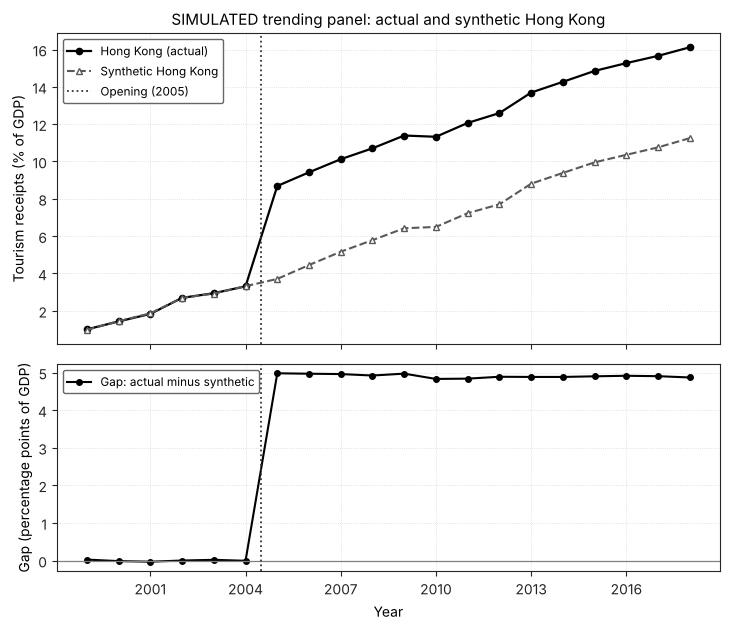

Figure saved: figures/sim_scm_hk.png


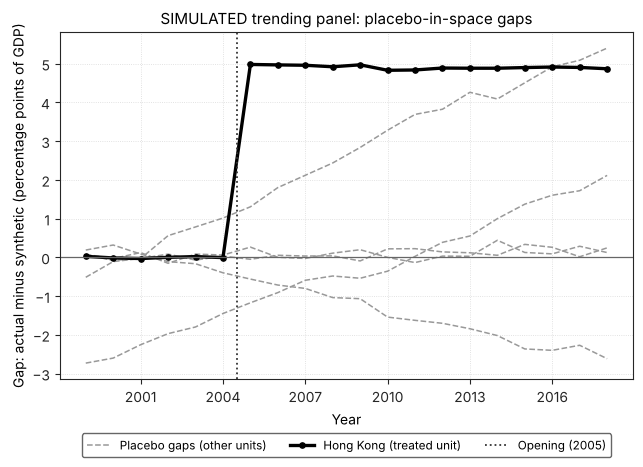

Figure saved: figures/sim_placebo_hk.png
PASS  placebo: treated unit ranks first by absolute mean gap when excluded from donor pools
PASS  placebo: the two pool conventions give different donor placebos


In [17]:
W, pre, first_post = scm_inputs(TRD, "hk")
years = W.index.to_numpy()
fit_hk = scm.synth(W.iloc[:, 0].to_numpy(), W.iloc[:, 1:].to_numpy(), pre, method="both", seed=SEEDS["synthetic control starts"])
names = [rp.UNIT_NAMES[u] for u in W.columns]

pl_excl = scm.placebo_in_space(W.to_numpy(), 0, pre, labels=names, exclude_treated=True)
pl_incl = scm.placebo_in_space(W.to_numpy(), 0, pre, labels=names, exclude_treated=False)
for title, pl in (("treated unit excluded from the placebo donor pools", pl_excl), ("treated unit kept in the placebo donor pools", pl_incl)):
    print(f"SIMULATED trending panel, Hong Kong block: {title}")
    print(pl.table[["unit", "pre_rmspe", "post_rmspe", "ratio", "mean_post_gap", "rank_ratio", "rank_abs_mean_gap"]].to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    print(f"permutation p-values: ratio {pl.p_value_ratio:.3f}, absolute mean gap {pl.p_value_abs_mean_gap:.3f}\n")

fig_scm(years, W.iloc[:, 0].to_numpy(), fit_hk.synthetic, first_post, "Hong Kong", "SIMULATED trending panel: actual and synthetic Hong Kong", "sim_scm_hk.png")
fig_placebo(years, pl_excl.gaps, names, "Hong Kong", first_post, "SIMULATED trending panel: placebo-in-space gaps", "sim_placebo_hk.png")
CHECK_D3 = {
    "placebo: treated unit ranks first by absolute mean gap when excluded from donor pools": int(pl_excl.table.rank_abs_mean_gap.iloc[0]) == 1,
    "placebo: the two pool conventions give different donor placebos": bool(not np.allclose(pl_excl.table.pre_rmspe.to_numpy()[1:], pl_incl.table.pre_rmspe.to_numpy()[1:])),
}
for k_, v_ in CHECK_D3.items():
    print(("PASS  " if v_ else "FAIL  ") + k_)
assert all(CHECK_D3.values())

### Part 3e. Event study (SIMULATED)

The event-study estimator is validated on the SIMULATED parallel panel, where the true effect path is zero before the opening and constant afterwards. The figure shows the Hong Kong coefficients with binned end points at -6 and +10 and base year -1, with the true path from the data-generating process.

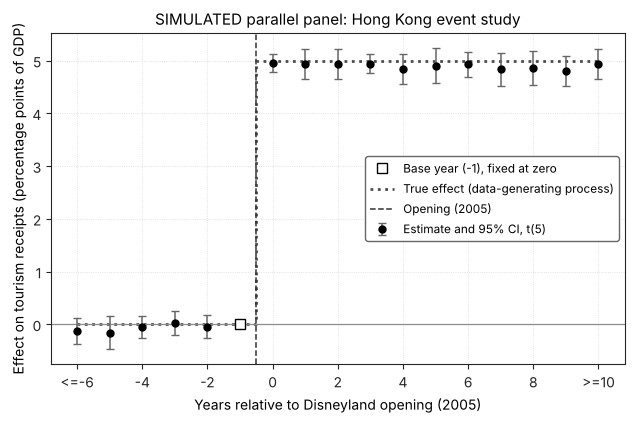

Figure saved: figures/sim_event_study_hk.png
SIMULATED: largest absolute pre-opening coefficient 0.156; mean post-opening coefficient 4.896 (true effect 5.0)
PASS  event study: pre-opening coefficients small (max |coef| < 0.6)
PASS  event study: mean post-opening coefficient within 0.5 of the true effect


In [18]:
hk_par = PAR[PAR.study_case == "Hong Kong"]
es = did.event_study(hk_par, lo=-6, hi=10, base=-1)
table = es.table.rename(columns={"ci_lo": "lo", "ci_hi": "hi"})
truth_path = pd.DataFrame({"rel": table.rel, "effect": np.where(table.rel >= 0, TRUTH_PAR.tau["Hong Kong"], 0.0)})
fig_event_study(
    table,
    base=-1,
    opening=2005,
    title="SIMULATED parallel panel: Hong Kong event study",
    fname="sim_event_study_hk.png",
    xticks=list(range(-6, 11, 2)),
    xlabels=["<=-6", "-4", "-2", "0", "2", "4", "6", "8", ">=10"],
    truth=truth_path,
    ci_label="Estimate and 95% CI, t(5)",
    legend_loc="center right",
)
pre_coefs = table[(table.rel < -1)].coef
post_coefs = table[table.rel >= 0].coef
print(f"SIMULATED: largest absolute pre-opening coefficient {pre_coefs.abs().max():.3f}; mean post-opening coefficient {post_coefs.mean():.3f} (true effect {TRUTH_PAR.tau['Hong Kong']:.1f})")
CHECK_E = {
    "event study: pre-opening coefficients small (max |coef| < 0.6)": bool(pre_coefs.abs().max() < 0.6),
    "event study: mean post-opening coefficient within 0.5 of the true effect": abs(post_coefs.mean() - TRUTH_PAR.tau["Hong Kong"]) < 0.5,
}
for k_, v_ in CHECK_E.items():
    print(("PASS  " if v_ else "FAIL  ") + k_)
assert all(CHECK_E.values())

### Figure inventory

Every figure of this notebook is saved as a PNG file in the directory figures. All figures are drawn in black and shades of gray; series are distinguished by line style, marker and hatching. The inventory lists the axis labels and the number of legend entries of each figure as recorded when it was saved, and checks the saved pixels: a figure is grayscale when the red, green and blue values of every pixel are identical.

In [19]:
import matplotlib.image as mpimg

rows = []
for rec in FIGURE_LOG:
    img = mpimg.imread(FIG / rec["file"])
    rgb = img[..., :3]
    spread = float(np.abs(rgb[..., 0] - rgb[..., 1]).max() + np.abs(rgb[..., 1] - rgb[..., 2]).max())
    rows.append({**rec, "width": img.shape[1], "height": img.shape[0], "channel spread": spread})
FIG_TABLE = pd.DataFrame(rows)
print(f"Figure inventory: {len(FIG_TABLE)} figures saved in {FIG.relative_to(ROOT) if FIG.is_relative_to(ROOT) else FIG}")
for r in rows:
    print(f"\n{r['file']}  ({r['width']} x {r['height']} pixels, {r['panels']} panel(s), {r['legend entries']} legend entries, channel spread {r['channel spread']:.1e})")
    print("  x axis: " + " | ".join(r["x labels"]))
    print("  y axis: " + " | ".join(r["y labels"]))
CHECK_F = {
    "every saved figure is grayscale (identical red, green and blue values in every pixel)": bool((FIG_TABLE["channel spread"] == 0).all()),
    "every figure has an x-axis label, a y-axis label and at least one legend entry": bool(
        all(len(r["x labels"]) > 0 and len(r["y labels"]) > 0 and r["legend entries"] > 0 for r in FIGURE_LOG)
    ),
    "every figure file is at least 600 pixels wide": bool((FIG_TABLE["width"] >= 600).all()),
}
print()
for k_, v_ in CHECK_F.items():
    print(("PASS  " if v_ else "FAIL  ") + k_)
assert all(CHECK_F.values())

Figure inventory: 8 figures saved in figures

ref_event_study_hk.png  (1029 x 676 pixels, 1 panel(s), 3 legend entries, channel spread 0.0e+00)
  x axis: Years relative to Disneyland opening (2005)
  y axis: Effect on tourism receipts (percentage points of GDP)

ref_event_study_sh.png  (1029 x 676 pixels, 1 panel(s), 3 legend entries, channel spread 0.0e+00)
  x axis: Years relative to Disneyland opening (2016)
  y axis: Effect on tourism receipts (percentage points of GDP)

ref_placebo_hk.png  (1647 x 709 pixels, 2 panel(s), 4 legend entries, channel spread 0.0e+00)
  x axis: Unit (ranked by ratio) | Unit (ranked by mean gap)
  y axis: Post/pre RMSPE ratio (unitless) | Mean post-opening gap (percentage points of GDP)

sim_monte_carlo.png  (1647 x 624 pixels, 2 panel(s), 6 legend entries, channel spread 0.0e+00)
  x axis: Estimated effect on Hong Kong receipts (percentage points of GDP)
  y axis: Number of simulated panels

sim_bootstrap_pvalue_function.png  (1035 x 794 pixels, 1 panel

### Summary of the checks

The table collects every criterion evaluated in Parts 1 and 3 and in the figure inventory. Each criterion was asserted in its own cell, so a failure would have stopped the notebook with an error at that point. The checks of Parts 1 and 3 do not depend on the real panel file. The row for the equivalence check against the real panel shows its status separately.

In [20]:
summary = []
summary.append(("Part 1", "closed-form SE relation within print rounding for all three reference samples", bool(SE_TABLE["within bound"].all())))
summary.append(("Part 1", "boottest t statistics follow from the estimation t with the documented K convention", bool(BOOT_T["within print rounding"].all())))
for group, checks in (("Part 3a", CHECK_A), ("Part 3b", CHECK_B), ("Part 3c", CHECK_C), ("Part 3d", {**CHECK_D1, **CHECK_D2, **CHECK_D3}), ("Part 3e", CHECK_E), ("Figures", CHECK_F)):
    for k_, v_ in checks.items():
        summary.append((group, k_, bool(v_)))
SUMMARY = pd.DataFrame(summary, columns=["part", "criterion", "result"])
SUMMARY["result"] = np.where(SUMMARY["result"], "PASS", "FAIL")
print("SIMULATED validation (Part 3) and reference-value checks (Part 1)")
print(SUMMARY.to_string(index=False))
print()
if REAL_RUN:
    counts = CHECK.status.value_counts().to_dict()
    print(f"Real-data check (Part 2): {counts}")
else:
    print("Real-data check: not run (set DTT_RUN_REAL=1 to run on the desktop)")
assert (SUMMARY["result"] == "PASS").all()

SIMULATED validation (Part 3) and reference-value checks (Part 1)
   part                                                                                           criterion result
 Part 1                       closed-form SE relation within print rounding for all three reference samples   PASS
 Part 1                 boottest t statistics follow from the estimation t with the documented K convention   PASS
Part 3a                                                     parallel panel: DiD unbiased (|bias| < 3 MC SE)   PASS
Part 3a                                       parallel panel: synthetic control unbiased (|bias| < 3 MC SE)   PASS
Part 3a                                                          trending panel: DiD biased (|bias| > 1 pp)   PASS
Part 3a                                 trending panel: synthetic control nearly unbiased (|bias| < 0.1 pp)   PASS
Part 3b clustered SE, p-values and CIs agree with closed forms and statsmodels (relative difference < 1e-9)   PASS
Part 3b       

### Scope and limits

The checks in Part 3 establish that the estimators, the estimation conventions, the exhaustive bootstrap and the synthetic-control solver are implemented correctly on data where the truth or an independent computation is available. The checks of Part 1 establish that the reference values are internally consistent. Neither establishes that the Python code reproduces the reference values on the real panel; this is what Part 2 tests when DTT_RUN_REAL=1 is set and data/raw/disney_did_panel.csv is present.

Three kinds of difference between the reference values and the Python output are expected on the real panel. The bootstrap p-values and confidence limits reported by boottest are Monte Carlo estimates from 9,999 draws, while the Python values are exact. The synthetic-control weights reported by synth come from a numerical optimiser, whereas the Python weights are the exact global optimum of the same problem, so the RMSPE may be lower in Python but not higher. The panel statistics reported by xtreg (sigma_u, sigma_e, rho, corr(u_i, Xb) and the between and overall R-squared) follow the documented definitions and can be confirmed only against the real panel.